# Voice Recognition with Whisper

The goal of this assignment is to use the pretrained Whisper model for voice recognition. The ´transformers´ library is used to load the model. The model is available in different sizes and in this notebook three are used to compare the results: tiny, base and large. Finnish recordings are used as input and the output is compared to the original text. The idea is to see how the different model sizes perform on the same input. The recordings are all under 30 seconds long and represent different categories: clean speech, dialect, background noise and whisper. The noisy audio is recorded with finnish news reading in the background as well as music. To capture the background noise accurately, the recordings needed to be recorded with setting the sound settings for audio enhancement to off to be able to capture the noise. There is also an english recording to see how the model performs on a different language even though the configured model language is Finnish. All recordings were made with Audacity's free audio recording software.

The recordings were transcribed into reference text to be able to calculate WER (word error rate) and compare results. The WER is calculated as the number of errors (substitutions, deletions and insertions) divided by the total number of words in the reference text. The lower the WER, the better the model performance. Inference time (the time required for the model to generate a transcription from audio) is recorded to analyze how model size affects speed by calculating the real-time factor (inference time divided by audio duration).

AI was used as a supporting tool to write code (especially for plots and WER-calculations), but analysis and interpretation of the results were done by the group. An overall analysis of transformer models based on this assignment and the text generation assignment, is found at the end of this notebook. 

Before the models and results are analyzed, the code takes the 01_clean_fi.wav recording as an example to show the spectogram and Mel spectogram to visualize and understand the audio data. 

In [1]:
import pandas as pd
import torch
import librosa
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Audio, display
from transformers import WhisperProcessor, WhisperForConditionalGeneration
import time
import seaborn as sns
import matplotlib.pyplot as plt
import re

audio_dir = "audio_samples/"

references = {
    "01_clear_fi.wav": "Lännestä saapuu lauantaina syvenevä matalapaine, joka liikkuu maan etelä- ja keskiosan yli kaakkoon tuoden lumi-, räntä- ja vesisateita, jotka ovat monin paikoin runsaita.",
    "02_dialect_fi.wav" : "Se otti messiin Marian, kenen kans se styylas vakkaristi. Maria oli paksuna. Just ku ne oli siel, Maria joutu telakalle.Se busas poitsun. Se oli sen eka skidi. Se duunas sille jotain kapaloi ja pani sen hegojen skruudimestaan, ku ne ei ollu onnannu skaffaan luukkuu hodlasta.",
    "03_noisybackground_fi.wav" : "Lännestä saapuu lauantaina syvenevä matalapaine, joka liikkuu maan etelä- ja keskiosan yli kaakkoon tuoden lumi-, räntä- ja vesisateita, jotka ovat monin paikoin runsaita.",
    "04_whisper_fi.wav" : "Lännestä saapuu lauantaina syvenevä matalapaine, joka liikkuu maan etelä- ja keskiosan yli kaakkoon tuoden lumi-, räntä- ja vesisateita, jotka ovat monin paikoin runsaita.",
    "05_simple_en.wav" : "A young whale is in the water near Germany. His name is Timmy. Timmy is very sick and tired. He cannot find the deep sea. He is all alone. A big fishing net hurts him. Now he is not strong enough to swim home."
}

In [2]:
# Example of clear audio file
audio_file = audio_dir + "01_clear_fi.wav"
y, sr = librosa.load(audio_file, sr=16000)

# Display audio for playback
print("Play the audio:")
display(Audio(y, rate=sr))

# Print audio statistics
duration = librosa.get_duration(y=y, sr=sr)
print(f"\nAudio Statistics:")
print(f"Duration: {duration:.2f} seconds")
print(f"Sample rate: {sr} Hz")

Play the audio:



Audio Statistics:
Duration: 12.92 seconds
Sample rate: 16000 Hz


In [3]:
def plot_audio_comparison(file1, file2, label1="Clear", label2="Noisy"):
    y1, sr1 = librosa.load(file1, sr=16000)
    y2, sr2 = librosa.load(file2, sr=16000)

    S1 = librosa.power_to_db(librosa.feature.melspectrogram(y=y1, sr=sr1, n_mels=128), ref=np.max)
    S2 = librosa.power_to_db(librosa.feature.melspectrogram(y=y2, sr=sr2, n_mels=128), ref=np.max)

    fig, axes = plt.subplots(2, 2, figsize=(16, 8))

    # ---------------- Waveforms ----------------
    librosa.display.waveshow(y1, sr=sr1, ax=axes[0, 0])
    axes[0, 0].set_title(f"{label1} - Waveform")

    librosa.display.waveshow(y2, sr=sr2, ax=axes[0, 1])
    axes[0, 1].set_title(f"{label2} - Waveform")

    # ---------------- Spectrograms ----------------
    img1 = librosa.display.specshow(
    S1, sr=sr1, x_axis="time", y_axis="mel", ax=axes[1, 0]
    )
    axes[1, 0].set_title("Clear - Mel Spectrogram")

    img2 = librosa.display.specshow(
        S2, sr=sr2, x_axis="time", y_axis="mel", ax=axes[1, 1]
    )
    axes[1, 1].set_title("Noisy Background - Mel Spectrogram")

    plt.tight_layout(rect=[0, 0.08, 1, 1])

    cbar_ax = fig.add_axes([0.2, 0.02, 0.6, 0.03])  

    cbar = fig.colorbar(img2, cax=cbar_ax, orientation="horizontal")
    cbar.set_label("Power (dB)")
    plt.show()

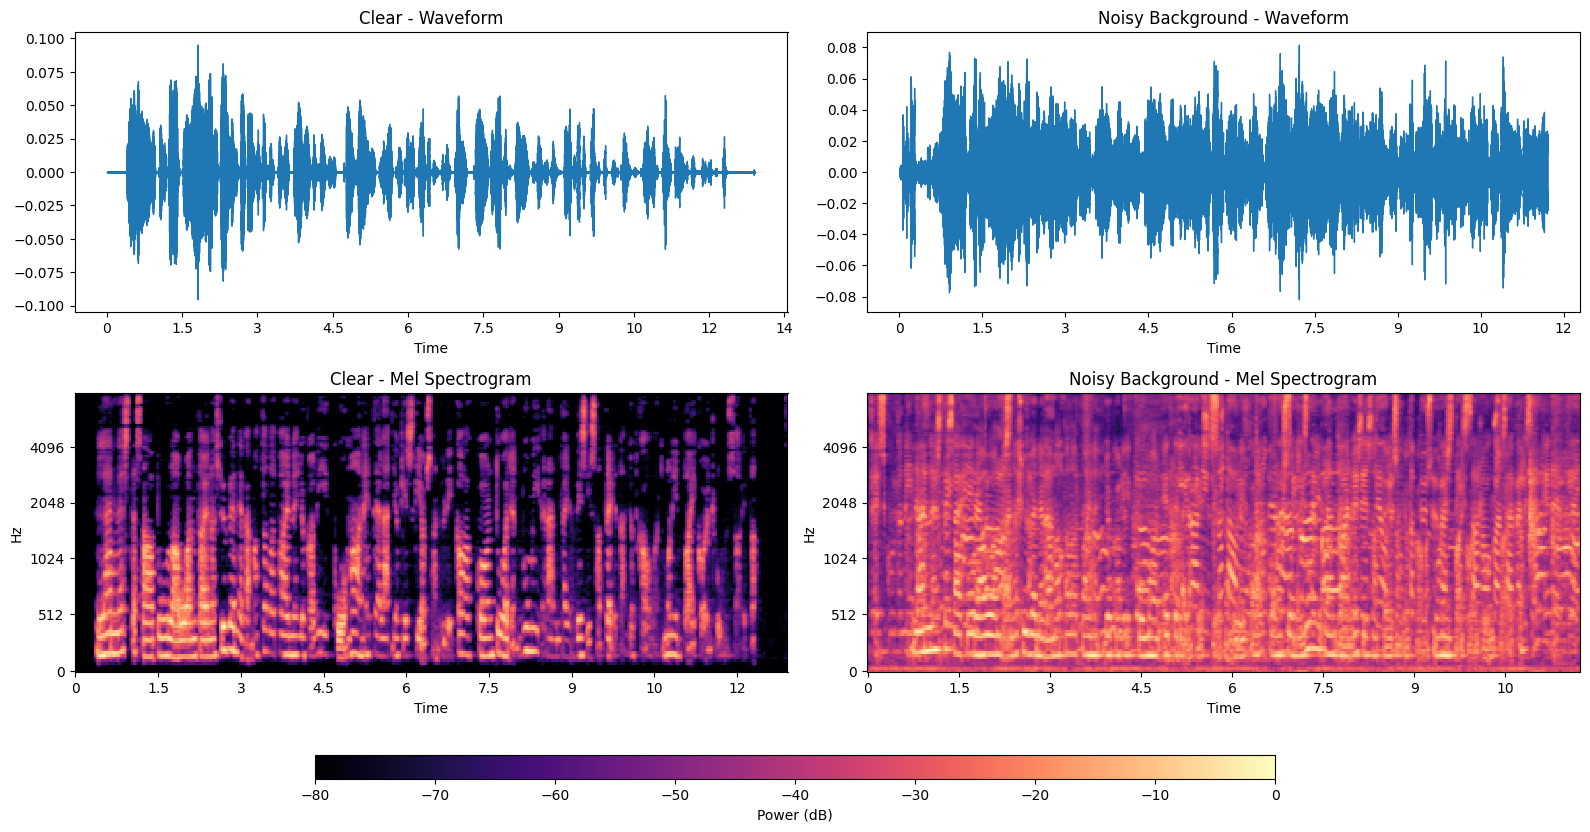

In [4]:
plot_audio_comparison(
    audio_dir + "01_clear_fi.wav",
    audio_dir + "03_noisybackground_fi.wav",
    label1="Clear",
    label2="Noisy Background"
)

Above are plotted the spectogram and Mel spectogram of the 01_clean_fi.wav recording compared with the 03_noisybackground_fi.wav recording. The spectogram shows the waveform (frequency, y-axis) of the audio signal and how it changes over time (x-axis). The Mel spectogram shows the same information but in a way that is more aligned with human hearing. Here too the x-axis is time and the y-axis is frequency, but the frequencies are spaced according to Mel scale. The Mel scale is logarithmic and gives more resolution to lower frequencies, which are important for speech recognition. The colors in the Mel spectogram represent signal energy (decibels) at different frequencies and times. Brighter and warmer colors signal stronger energy while darker and cooler colors signal weaker energy. 

The decibels are relative to peak power meaning that 0 is the maximum energy in the signal. This is visible in the Mel spectogram when comparing the clear audio with the noisy audio. The latter has a uniformly lighter color indicating constant high energy across frequencies and time. The clear audio has more variation in color indicating that the energy is not constant and there are moments of silence or low energy. The model needs the variation in energy to be able to recognize speech and the constant high energy in the noisy recording will make it more difficult for the models to recognize the speech and will likely lead to higher WER. The spectogram is also turned into a 2D time-frequency representation of the audio signal, which is similar in structure to images, which work well with the Transformer architecture.

The Whisper model is a Transformer-based model and originally designed for sequences like the text-task, but with voice recognition it now processes audio spectogram tokens instead of text tokens. Self-attention is used to capture the relationships between different parts of the audio signal, which helps the model to understand the context and meaning of the speech. The model is trained on a large dataset of audio and text pairs, which allows it to learn how to transcribe speech into text. The different sizes of the model (tiny, base and large) have different numbers of parameters and layers, which affects their performance and speed. 

Next is the code for loading and running the models. The chosen sizes were tiny, base and large to get a wide range of results. WER is used to compare the results and inference time is recorded to analyze how model size affects speed. The target language is set to Finnish and results are saved in a dataframe and csv file for the possibility to analyze again later. The results are shown below the execution code. 

In [5]:
def wer(ref, hyp):
    ref_words = ref.lower().split()
    hyp_words = hyp.lower().split()

    d = [[0] * (len(hyp_words)+1) for _ in range(len(ref_words)+1)]

    for i in range(len(ref_words)+1):
        d[i][0] = i
    for j in range(len(hyp_words)+1):
        d[0][j] = j

    for i in range(1, len(ref_words)+1):
        for j in range(1, len(hyp_words)+1):
            cost = 0 if ref_words[i-1] == hyp_words[j-1] else 1
            d[i][j] = min(
                d[i-1][j] + 1,
                d[i][j-1] + 1,
                d[i-1][j-1] + cost
            )

    return d[-1][-1] / len(ref_words)

In [6]:
device = "cpu"

model_names = {
    "tiny": "openai/whisper-tiny",
    "base": "openai/whisper-base",
    "large": "openai/whisper-large-v3"
}

models = {}
processors = {}

for name, hf_name in model_names.items():
    print(f"Loading {name}")

    processors[name] = WhisperProcessor.from_pretrained(hf_name)

    models[name] = WhisperForConditionalGeneration.from_pretrained(
        hf_name,
        torch_dtype=torch.float32
    ).to(device)

Loading tiny


Loading weights:   0%|          | 0/167 [00:00<?, ?it/s]

Loading base


Loading weights:   0%|          | 0/245 [00:00<?, ?it/s]

Loading large


Loading weights:   0%|          | 0/1259 [00:00<?, ?it/s]

In [7]:
results = []

for model_name in models:
    model = models[model_name]
    processor = processors[model_name]

    forced_decoder_ids = processor.get_decoder_prompt_ids(language="fi", task="transcribe")

    for file, ref_text in references.items():
        path = audio_dir + file

        print(f"{model_name} -> {file}")

        y, sr = librosa.load(path, sr=16000)
        duration = librosa.get_duration(y=y, sr=sr)

        start = time.time()

        input_features = processor(y, sampling_rate=sr, return_tensors="pt").input_features
        input_features = input_features.to(device).float()

        with torch.no_grad():
            predicted_ids = model.generate(input_features)

        transcription = processor.batch_decode(predicted_ids, skip_special_tokens=True)[0]

        end = time.time()

        error = wer(ref_text, transcription)
        inference_time = end - start
        real_time = inference_time / duration

        results.append({
            "file": file,
            "model": model_name,
            "ref": ref_text,
            "hyp": transcription,
            "wer": error,
            "time_sec": inference_time,
            "real_time": real_time
        })

[transformers] Using custom `forced_decoder_ids` from the (generation) config. This is deprecated in favor of the `task` and `language` flags/config options.
[transformers] Transcription using a multilingual Whisper will default to language detection followed by transcription instead of translation to English. This might be a breaking change for your use case. If you want to instead always translate your audio to English, make sure to pass `language='en'`. See https://github.com/huggingface/transformers/pull/28687 for more details.


tiny -> 01_clear_fi.wav


[transformers] The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
[transformers] A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. The custom <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> will take precedence. Please check the docstring of <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> to see related `.generate()` flags.
[transformers] A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensAtBeginLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. The custom <class 'transform

tiny -> 02_dialect_fi.wav
tiny -> 03_noisybackground_fi.wav
tiny -> 04_whisper_fi.wav
tiny -> 05_simple_en.wav
base -> 01_clear_fi.wav
base -> 02_dialect_fi.wav
base -> 03_noisybackground_fi.wav
base -> 04_whisper_fi.wav
base -> 05_simple_en.wav
large -> 01_clear_fi.wav
large -> 02_dialect_fi.wav
large -> 03_noisybackground_fi.wav
large -> 04_whisper_fi.wav
large -> 05_simple_en.wav


Below are the results of the different models and their recordings. At initial glance it seems that the tiny model hallucinates language even though the target language is set to Finnish. The base model performs almost as good as the large model and is a lot faster. All models are able to transcribe the english recording. The noisy recording is the most difficult for the models to interpet, but that was expected based on the spectograms. When looking at the WER, the large model outperforms both the two smaller models, but when inspecting at the models hypotheses, the base model produces more finnish-like text and it is close to the reference text. 

In [8]:
df = pd.DataFrame(results)
df.to_csv("whisper_results.csv", index=False)
df

,file,model,ref,hyp,wer,time_sec,real_time
0,01_clear_fi.wav,tiny,Lännestä saapuu lauantaina syvenevä matalapain...,Lennestä saa puulla on tällaista syvennevämmä...,0.739130,2.276292,0.176228
1,02_dialect_fi.wav,tiny,"Se otti messiin Marian, kenen kans se styylas ...",Se otte mestiin marjankenen kanssa se stylasv...,0.844444,2.282748,0.147170
2,03_noisybackground_fi.wav,tiny,Lännestä saapuu lauantaina syvenevä matalapain...,"Nämä on näistä saa hieman, että syvenerä on m...",1.086957,1.752083,0.149595
3,04_whisper_fi.wav,tiny,Lännestä saapuu lauantaina syvenevä matalapain...,"Lenni éstez a púlámmant, a helyes jövénemem, ...",1.391304,2.229097,0.178594
4,05_simple_en.wav,tiny,A young whale is in the water near Germany. Hi...,"A young wail is in the water, near Germany, h...",0.090909,1.557792,0.099848
5,01_clear_fi.wav,base,Lännestä saapuu lauantaina syvenevä matalapain...,Lännestä saa puhlauantaina syvenevämätala pai...,0.608696,3.311831,0.256398
6,02_dialect_fi.wav,base,"Se otti messiin Marian, kenen kans se styylas ...",Se ottimestiin mariankenen kanssa se styylasv...,0.822222,3.824148,0.246545
7,03_noisybackground_fi.wav,base,Lännestä saapuu lauantaina syvenevä matalapain...,Näin näistä sähinua on tänä syvenevää matalap...,1.000000,3.020244,0.257872
8,04_whisper_fi.wav,base,Lännestä saapuu lauantaina syvenevä matalapain...,Lällestä saa puulauvan tai nasi venevää mata ...,0.913043,3.136723,0.251312
9,05_simple_en.wav,base,A young whale is in the water near Germany. Hi...,A young whale is in the water near Germany. H...,0.000000,2.611699,0.167400


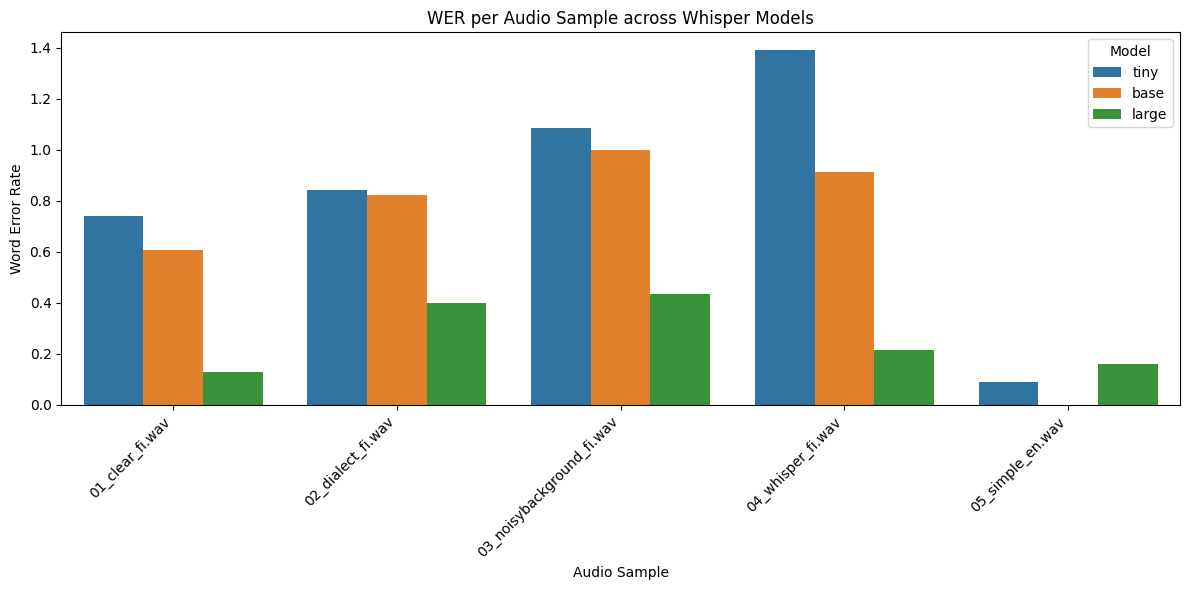

In [9]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=df,
    x="file",
    y="wer",
    hue="model"
)

plt.title("WER per Audio Sample across Whisper Models")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Word Error Rate")
plt.xlabel("Audio Sample")
plt.legend(title="Model")

plt.tight_layout()
plt.show()

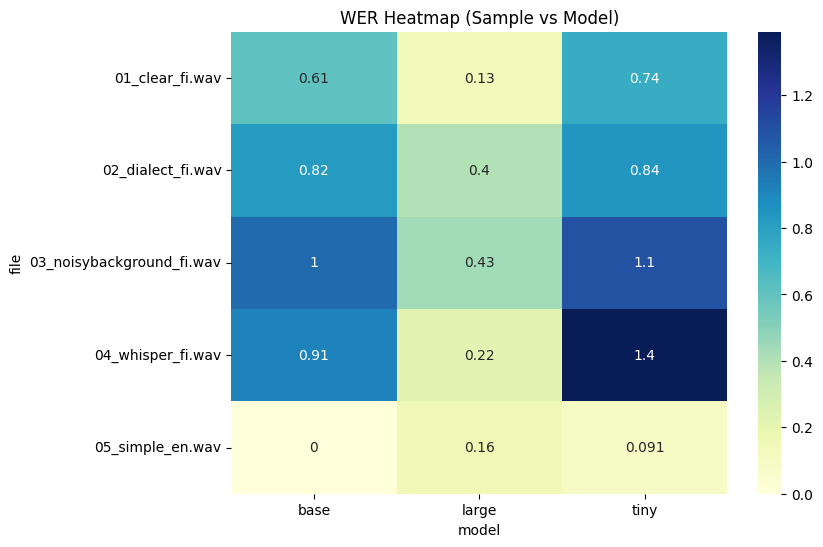

In [10]:
pivot = df.pivot(index="file", columns="model", values="wer")

plt.figure(figsize=(8,6))
sns.heatmap(pivot, annot=True, cmap="YlGnBu")
plt.title("WER Heatmap (Sample vs Model)")
plt.show()

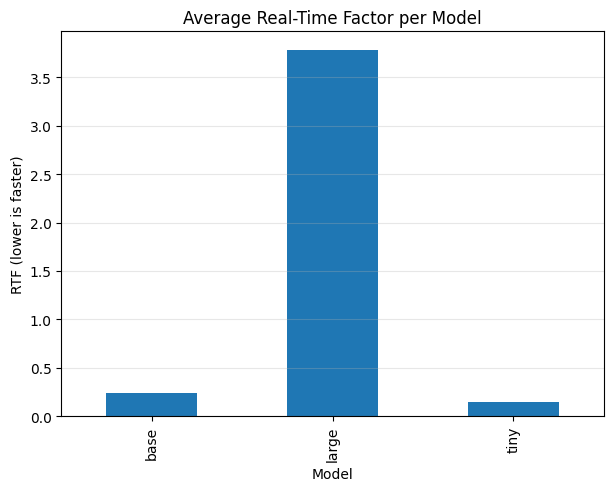

In [17]:
plt.figure(figsize=(7,5))

df.groupby("model")["real_time"].mean().plot(kind="bar")

plt.title("Average Real-Time Factor per Model")
plt.ylabel("RTF (lower is faster)")
plt.xlabel("Model")

plt.grid(axis="y", alpha=0.3)
plt.show()

As seen on the plots, the large model clearly outperforms the base and tiny models. Both the smaller models have a RTF of less than 1, which means that they can transcribe audio faster than real time. A value of 1 would mean that the model takes as long as the audio duration to transcribe it. The large model has a RTF of over 3 which means it takes is three times longer to transcribe the audio than the actual audio duration. The large model is more accurate, but clearly much slower. In these test cases it clearly wins as the durations are short, but for longer audio files the inference time would be a lot longer and then the base model might be a better choice as it is much faster and still produces good results even if the WER is not that much better than with the tiny model. The tiny model had nonsense and language hallucination in its transcriptions which made it clearly the worst performing model. 

There was a thought about how punctuations and such would affect WER and whether it would be better to remove them from the reference text and hypotheses before calculating WER. Below are the results of the WER calculations compared with normalized WER calculations where punctuation and capitalization were removed. This did not have a significant effect so the results do not need to be compared with normalized WER. 

In [12]:

def normalize(text):
    text = text.lower()
    text = re.sub(r"[^\w\s]", "", text)  # remove punctuation
    return text

df["ref_norm"] = df["ref"].apply(normalize)
df["hyp_norm"] = df["hyp"].apply(normalize)

wer_values = []
for idx, row in df.iterrows():
    error = wer(row["ref_norm"], row["hyp_norm"])
    wer_values.append(error)
df["wer_norm"] = wer_values
df[["file", "model", "wer", "wer_norm"]]

,file,model,wer,wer_norm
0,01_clear_fi.wav,tiny,0.739130,0.739130
1,02_dialect_fi.wav,tiny,0.844444,0.822222
2,03_noisybackground_fi.wav,tiny,1.086957,1.086957
3,04_whisper_fi.wav,tiny,1.391304,1.391304
4,05_simple_en.wav,tiny,0.090909,0.022727
5,01_clear_fi.wav,base,0.608696,0.521739
6,02_dialect_fi.wav,base,0.822222,0.822222
7,03_noisybackground_fi.wav,base,1.000000,1.000000
8,04_whisper_fi.wav,base,0.913043,0.913043
9,05_simple_en.wav,base,0.000000,0.000000


To be able to better compare the interesting cases of the transcriptions, a function was created to show them in a more clear way with less columns. The chosen interesting cases are 01_clear_fi.wav, 02_dialect_fi.wav and 03_noisybackground_fi.wav. The clear one shows the easiest and best case scenario for the models whereas the dialect one shows how the models perform with a different dialect. The noisy one was chosen as it would be interesting to see if the models will output text from the noise as well as the actual speaking. Lastly also the english recording is compared to see how the models perform with a different language than the configured one.

In [ ]:
def show_file_comparison(df, filename):
    subset = df[df["file"] == filename].copy()

    subset = subset[["model", "ref", "hyp", "wer", "time_sec"]]

    return subset.sort_values("model")

In [19]:
pd.set_option("display.max_colwidth", None)

show_file_comparison(df, "01_clear_fi.wav")

,model,ref,hyp,wer,time_sec
5,base,"Lännestä saapuu lauantaina syvenevä matalapaine, joka liikkuu maan etelä- ja keskiosan yli kaakkoon tuoden lumi-, räntä- ja vesisateita, jotka ovat monin paikoin runsaita.","Lännestä saa puhlauantaina syvenevämätala painen, joka liikkua maan etelät, jokiski osan yli kalkkoon, tuoden lumi, räntä ja vesisa teitä, jotka ovat monin paikoin rumsaita.",0.608696,3.311831
10,large,"Lännestä saapuu lauantaina syvenevä matalapaine, joka liikkuu maan etelä- ja keskiosan yli kaakkoon tuoden lumi-, räntä- ja vesisateita, jotka ovat monin paikoin runsaita.","Lännestä saapuu lauantaina syvenevä matalapaine, joka liikkuu maan etelä ja keskiosan yli kaakkoon tuoden lumiräntä ja vesisateita, jotka ovat monin paikoin runsaita.",0.130435,49.681832
0,tiny,"Lännestä saapuu lauantaina syvenevä matalapaine, joka liikkuu maan etelä- ja keskiosan yli kaakkoon tuoden lumi-, räntä- ja vesisateita, jotka ovat monin paikoin runsaita.","Lennestä saa puulla on tällaista syvennevämmä, että liikkua maaneet ja lähtöjä kiosan yli kalkkoon, tuoden lumiirändä ja visissa teetä, jotka ovat monin paikoin lumsaita.",0.739130,2.276292


This shows that the large model outputs an accurate transcription for the clear recording. The WER score here is slightly higher than expected from the correct output, but here probably the punctuations and dashes have an effect. The base model outputs a transcription that is close to the reference text but the WER score is low as the words are not correct. The message is still somewhat understandable from the hypothesis. The tiny model outputs a transcription that is not comparable with the reference text and is not understandable. 

In [20]:
show_file_comparison(df, "02_dialect_fi.wav")

,model,ref,hyp,wer,time_sec
6,base,"Se otti messiin Marian, kenen kans se styylas vakkaristi. Maria oli paksuna. Just ku ne oli siel, Maria joutu telakalle.Se busas poitsun. Se oli sen eka skidi. Se duunas sille jotain kapaloi ja pani sen hegojen skruudimestaan, ku ne ei ollu onnannu skaffaan luukkuu hodlasta.","Se ottimestiin mariankenen kanssa se styylasvakkaristi, marialipaksuna. Juskun oli siellä, Maria joututela kalle, se busaspoitsun, sovisen ekkaskipi, se duunnassa leitö tai kapaloja, panisen heikojen skruudimestaan, kun ei ole oannonuskappaan luukkuuhodlast.",0.822222,3.824148
11,large,"Se otti messiin Marian, kenen kans se styylas vakkaristi. Maria oli paksuna. Just ku ne oli siel, Maria joutu telakalle.Se busas poitsun. Se oli sen eka skidi. Se duunas sille jotain kapaloi ja pani sen hegojen skruudimestaan, ku ne ei ollu onnannu skaffaan luukkuu hodlasta.","Se otti messiin Marian, kenen kanssa se styylas vakkaristi. Maria oli paksunut. Just kun ne oli siellä, Maria joutui telakalle. Se busas poitsun, se oli sen ekas kivi. Se duunasi sille jotain kapaloa ja pani sen hekojen skruudimestaan, kun ei ollut onnannuskaffaan luukkuu hodlasta.",0.400000,58.974392
1,tiny,"Se otti messiin Marian, kenen kans se styylas vakkaristi. Maria oli paksuna. Just ku ne oli siel, Maria joutu telakalle.Se busas poitsun. Se oli sen eka skidi. Se duunas sille jotain kapaloi ja pani sen hegojen skruudimestaan, ku ne ei ollu onnannu skaffaan luukkuu hodlasta.","Se otte mestiin marjankenen kanssa se stylasvakkaalisti, marjali paksona. Juskun olisi ja marja joututelakalli se pusas poitsun, saali sen eikäskipi, se tunnasti lejotaan kapaaloi ja panisen hekojen skruudimestaan, kun ei ole onnan oskaatvaa luukkuuhoitlast.",0.844444,2.282748


For the dialect recording, the large one outputs almost outputs the fully correct transcription and it is understandable. The base model combines words together and has some very weird words in the transcription making it almost unreadable. The tiny model again outputs a transcription that is barely comparable with the reference text. 

In [21]:
show_file_comparison(df, "03_noisybackground_fi.wav")

,model,ref,hyp,wer,time_sec
7,base,"Lännestä saapuu lauantaina syvenevä matalapaine, joka liikkuu maan etelä- ja keskiosan yli kaakkoon tuoden lumi-, räntä- ja vesisateita, jotka ovat monin paikoin runsaita.","Näin näistä sähinua on tänä syvenevää matalapain, joka pitkuu maan etelijäkisesä, kulikaarot on suolimmin, tai ne sisältelys on jotapuus mun mielestäni saada ruoksaäveliset.",1.000000,3.020244
12,large,"Lännestä saapuu lauantaina syvenevä matalapaine, joka liikkuu maan etelä- ja keskiosan yli kaakkoon tuoden lumi-, räntä- ja vesisateita, jotka ovat monin paikoin runsaita.","Lämmistä saapuu lauantaina syvenevä matala paine, joka liikkuu maan etelä- ja keski-osan yli kaupungin suoneen lumi- ja rantainvesisateen, jotka ovat monin paikoin tunsaita.",0.434783,51.205584
2,tiny,"Lännestä saapuu lauantaina syvenevä matalapaine, joka liikkuu maan etelä- ja keskiosan yli kaakkoon tuoden lumi-, räntä- ja vesisateita, jotka ovat monin paikoin runsaita.","Nämä on näistä saa hieman, että syvenerä on matalapainen, joka liittyen maan eteliä kiesissa saa, kun on ruttia nusselisten pääntoaineissa, että olisi on jota pysyjää.",1.086957,1.752083


With the noisy recording, it is surprising how good the large model is able to transcribe the audio. It is understandable and might have picked up words from the other sounds on the audio rather than the actual speech. The base and tiny models outputs are word salad and perhaps picking up words from the noise more than the large model. For all the models, it is not clear how the words are mixed as none of the wrong words are clearly from either of the noisy sources (music and news reading).


In [23]:
show_file_comparison(df, "05_simple_en.wav")

,model,ref,hyp,wer,time_sec
9,base,A young whale is in the water near Germany. His name is Timmy. Timmy is very sick and tired. He cannot find the deep sea. He is all alone. A big fishing net hurts him. Now he is not strong enough to swim home.,A young whale is in the water near Germany. His name is Timmy. Timmy is very sick and tired. He cannot find the deep sea. He is all alone. A big fishing net hurts him. Now he is not strong enough to swim home.,0.000000,2.611699
14,large,A young whale is in the water near Germany. His name is Timmy. Timmy is very sick and tired. He cannot find the deep sea. He is all alone. A big fishing net hurts him. Now he is not strong enough to swim home.,a young whale is in the water near germany his name is timmy timmy is very sick and tired he cannot find the deep sea he is all alone a big fishing net hurts him now he is not strong enough to swim home,0.159091,45.466326
4,tiny,A young whale is in the water near Germany. His name is Timmy. Timmy is very sick and tired. He cannot find the deep sea. He is all alone. A big fishing net hurts him. Now he is not strong enough to swim home.,"A young wail is in the water, near Germany, his name is Timmy. Timmy is very sick and tired. He cannot find the deep sea, he is all alone. A big fishing net hurts him. Now he is not strong enough to swim home.",0.090909,1.557792



Interestingly, the large model performs worst when using the un-normalized WER, but as is seen in the texts above, the large model does not use capitalization and punctuation in its transcriptions, which is likely the reason for the higher WER. The base and tiny models use more punctuation and capitalization, which might be the reason for their slightly better WER scores with the un-normalized WER. Why this is the case for just the large model, is not clear as all models were configured the same way. The Finnish language has a different structure when it comes to captialization, but why the large now is outperformed by the smaller models in this way is not clear. When asking AI (ChatGPT) about this, it was not able to give a clear answer and offered vague explanations about decoding priors and behaviour and linguistic formattings. 

All in all, the large model clearly outperforms the other two and the tiny model is cleary worse than the base model even if they got similar WER and RTF scores. The tiny model hallucinated language and the outputed hypotheses were not as understandable as the base model´s output. The large model is much slower than the smaller ones, which is its main downside. In this experimentation the difference in RTF for small and tiny were basically the same, so the base model should be chosen over the tiny model in most cases. This is especially for when the transcription is needed quickly and the audio is not too difficult for the model to process. For all cases where the accuracy is more important than the speed and if the audio is not that noisy or otherwise challenging, the large model should be chosen as it works best in all (finnish, the configured language) cases.

The smaller models could be used in cases with real-time transcription needs such as live subtitle generation or voice assistants. The large model could be used in settings where the transcription is not needed immediately and also when the accuracy is a main concern as in legal and medical settings. 

# Transformer models - overall analysis

Transformers are powerful model that have made a significant impact in the field of language processing. Larger models are generally more accurate, but also significantly slower. And as the text generation assignment showed, the data used for training the model is important and affects the results. Performance is also dependant on preprocessing and tokenization. In the text generation assignment the tokenization did not produce enough tokens and the model was not able to learn properly, but this was probably because the book should have been longer or used a combination of books to produce more training data. In the voice recognition assignment the preprocessing could be achieved by getting rid of the noise and highlight the actual speech, but these are not always possible especially in real-time. How the correct model is chosen, depends on the use case and whether the requirements focus on speed or accuracy or a balance of the two. 